# Technique 5: Feature Selection / Feature Analysis**Group ID:** 2026-Y2-S1-MET-18**Member:** Seniri G.H.M.D.M | IT25102123Credit Risk Dataset — individual contribution notebook, extracted from `group_pipeline.ipynb`.

In [ ]:
# ==============================# SETUP: Load the Credit Risk dataset# (Shared setup step used across the group pipeline)# ==============================import pandas as pdimport numpy as npimport matplotlib.pyplot as pltimport seaborn as snsimport kagglehubimport os# Download latest version of the datasetpath = kagglehub.dataset_download("laotse/credit-risk-dataset")print("Path to dataset files:", path)print("\nFiles in dataset folder:")print(os.listdir(path))# Load the datasetfile_path = os.path.join(path, "credit_risk_dataset.csv")df = pd.read_csv(file_path)print("\nDataset loaded successfully!")print(df.head())

In [ ]:
# ==============================# PREREQUISITE: Basic cleaning inherited from the group pipeline# (duplicate removal + missing value handling, done earlier by#  Members 1 and 2, reproduced here so this notebook runs standalone)# ==============================df = df.drop_duplicates()if "person_emp_length" in df.columns:    df["person_emp_length"] = df["person_emp_length"].fillna(        df["person_emp_length"].median()    )if "loan_int_rate" in df.columns:    df["loan_int_rate"] = df["loan_int_rate"].fillna(        df["loan_int_rate"].median()    )print("Shape after cleaning:", df.shape)

---
## Technique 5: Feature Analysis / Selection
 **Section owner:
Seniri  G.H.M.D.M | IT25102123**

Same as Lab 3 Step 6 / Lab 4 — correlate every feature against the target and use the heatmap to decide what to drop, instead of feature-vs-feature.

Correlation Matrix:
                            person_age  person_income  person_emp_length  \
person_age                    1.000000       0.173293           0.161342   
person_income                 0.173293       1.000000           0.134791   
person_emp_length             0.161342       0.134791           1.000000   
loan_amnt                     0.050680       0.265947           0.113934   
loan_int_rate                 0.011074       0.000826          -0.051462   
loan_status                  -0.022698      -0.145005          -0.082517   
loan_percent_income          -0.042300      -0.254472          -0.054024   
cb_person_cred_hist_length    0.859215       0.117614           0.143251   

                            loan_amnt  loan_int_rate  loan_status  \
person_age                   0.050680       0.011074    -0.022698   
person_income                0.265947       0.000826    -0.145005   
person_emp_length            0.113934      -0.051462    -0.082517   
loan_amnt          

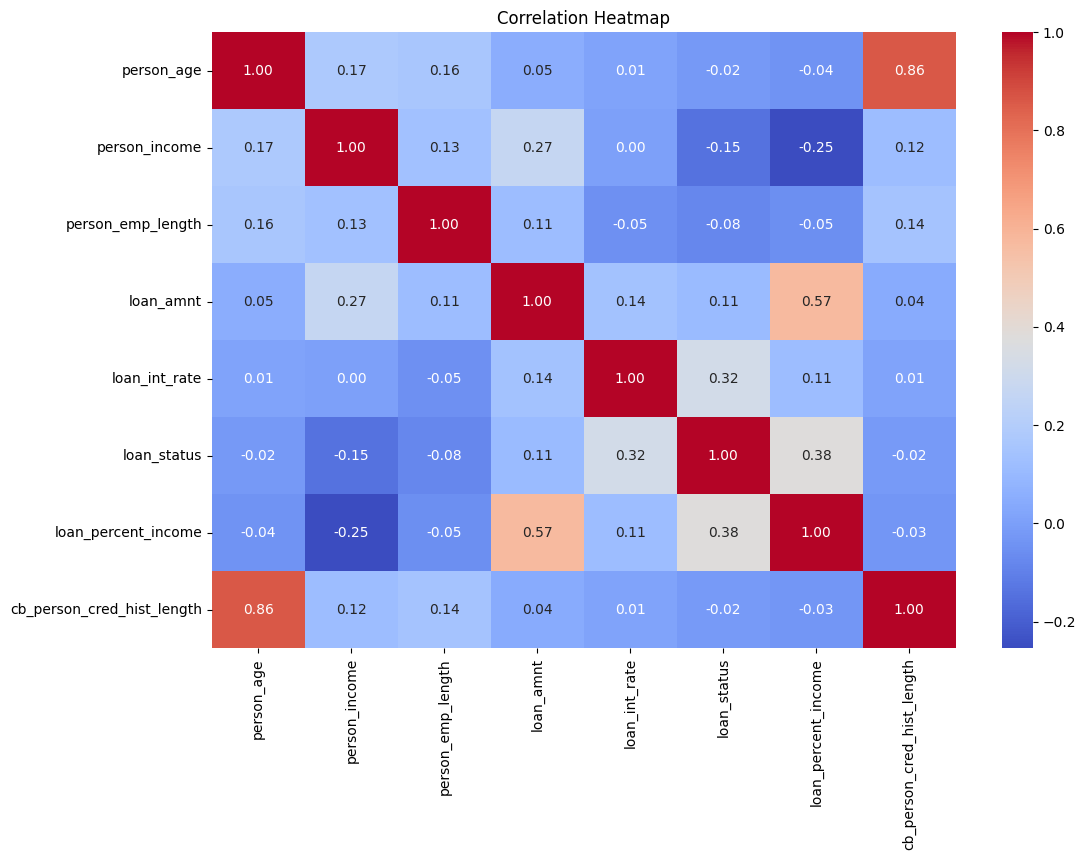


X Shape:
(32416, 11)

y Shape:
(32416,)

Input Features:
Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file',
       'cb_person_cred_hist_length'],
      dtype='object')

Target:
loan_status

Numerical Features:
['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

Categorical Features:
['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


In [ ]:
# ==============================
# MEMBER 5
# Feature Analysis + X and y
# ==============================

# Select numerical columns
numeric_df = df.select_dtypes(include=["int64", "float64"])

# Correlation matrix
correlation_matrix = numeric_df.corr()

print("Correlation Matrix:")
print(correlation_matrix)


# Correlation heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()


# Define input features X
X = df.drop("loan_status", axis=1)

# Define target variable y
y = df["loan_status"]

print("\nX Shape:")
print(X.shape)

print("\ny Shape:")
print(y.shape)

print("\nInput Features:")
print(X.columns)

print("\nTarget:")
print(y.name)


# Identify numerical features
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Identify categorical features
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("\nNumerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)